In [1]:
!pip install google-genai tqdm -q

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
anyscale 0.5.131 requires pydantic<2,>=1.9.0, but you have pydantic 2.12.5 which is incompatible.
fastapi 0.95.2 requires pydantic!=1.7,!=1.7.1,!=1.7.2,!=1.7.3,!=1.8,!=1.8.1,<2.0.0,>=1.6.2, but you have pydantic 2.12.5 which is incompatible.
great-expectations 0.16.5 requires pydantic<2.0,>=1.9.2, but you have pydantic 2.12.5 which is incompatible.


In [2]:
import google as genai


# Load Data

In [3]:
import pandas as pd

In [4]:
# Load training data
DATASET_LOC = "https://raw.githubusercontent.com/GokuMohandas/Made-With-ML/main/datasets/dataset.csv"
train_df = pd.read_csv(DATASET_LOC)
train_df.head()

,id,created_on,title,description,tag
0,6,2020-02-20 06:43:18,Comparison between YOLO and RCNN on real world...,Bringing theory to experiment is cool. We can ...,computer-vision
1,7,2020-02-20 06:47:21,"Show, Infer & Tell: Contextual Inference for C...",The beauty of the work lies in the way it arch...,computer-vision
2,9,2020-02-24 16:24:45,Awesome Graph Classification,"A collection of important graph embedding, cla...",other
3,15,2020-02-28 23:55:26,Awesome Monte Carlo Tree Search,A curated list of Monte Carlo tree search pape...,other
4,25,2020-03-07 23:04:31,AttentionWalk,"A PyTorch Implementation of ""Watch Your Step: ...",other


In [5]:
# Unique labels
tags = train_df.tag.unique().tolist()
tags

['computer-vision', 'other', 'natural-language-processing', 'mlops']

In [6]:
# Load inference dataset
HOLDOUT_LOC = "https://raw.githubusercontent.com/GokuMohandas/Made-With-ML/main/datasets/holdout.csv"
test_df = pd.read_csv(HOLDOUT_LOC)

In [10]:
len(test_df)

191

# Utilities Func

In [11]:
import json
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns; sns.set_theme()
from sklearn.metrics import precision_recall_fscore_support
import time
from tqdm import tqdm

In [18]:
!pip uninstall google google-generativeai -y
!pip install google-genai

Found existing installation: google-generativeai 0.8.6
Uninstalling google-generativeai-0.8.6:
  Successfully uninstalled google-generativeai-0.8.6


In [20]:
from google import genai
from dotenv import load_dotenv
import os

# Load env
load_dotenv()

client = genai.Client(api_key=os.getenv("GEMINI_API_KEY"))

# Original components
system_content = "you only answer in rhymes"
assistant_content = ""
user_content = "how are you"

# Reconstruct structured prompt
contents = f"""
System: {system_content}

Assistant: {assistant_content}

User: {user_content}
"""

response = client.models.generate_content(
    model="gemini-2.5-flash-lite",
    contents=contents
)

print(response.text)

I'm doing quite well, it's true,
And how are you, my friend, today?


In [22]:
def get_tag(model, system_content="", assistant_content="", user_content=""):
    try:
        prompt = f"""
You must return ONLY the final tag. No explanation.

System: {system_content}

Assistant: {assistant_content}

User: {user_content}
"""

        response = client.models.generate_content(
            model=model,
            contents=prompt
        )

        return response.text.strip()

    except Exception as e:
        print(f"Gemini error: {e}")
        return None

In [42]:
model = "gemini-2.5-flash-lite"
system_context = f"""
    You are a NLP prediction service that predicts the label given an input's title and description.
    You must choose between one of the following labels for each input: {tags}.
    Only respond with the label name and nothing else.
    """
assistant_content = ""
user_context = "Transfer learning with transformers: Using transformers for transfer learning on text classification tasks."
tag = get_tag(model=model, system_content=system_context, assistant_content=assistant_content, user_content=user_context)
print (tag)

natural-language-processing


In [38]:
# List of dicts w/ {title, description} (just the first 3 samples for now)
samples = test_df[["title", "description"]].to_dict(orient="records")[:3]
samples


[{'title': 'Diffusion to Vector',
  'description': 'Reference implementation of Diffusion2Vec (Complenet 2018) built on Gensim and NetworkX. '},
 {'title': 'Graph Wavelet Neural Network',
  'description': 'A PyTorch implementation of "Graph Wavelet Neural Network" (ICLR 2019) '},
 {'title': 'Capsule Graph Neural Network',
  'description': 'A PyTorch implementation of "Capsule Graph Neural Network" (ICLR 2019).'}]

In [39]:
test_df[["title", "description", "tag"]].to_dict(orient="records")[:3]

[{'title': 'Diffusion to Vector',
  'description': 'Reference implementation of Diffusion2Vec (Complenet 2018) built on Gensim and NetworkX. ',
  'tag': 'other'},
 {'title': 'Graph Wavelet Neural Network',
  'description': 'A PyTorch implementation of "Graph Wavelet Neural Network" (ICLR 2019) ',
  'tag': 'other'},
 {'title': 'Capsule Graph Neural Network',
  'description': 'A PyTorch implementation of "Capsule Graph Neural Network" (ICLR 2019).',
  'tag': 'other'}]

In [43]:
from concurrent.futures import ThreadPoolExecutor, as_completed
from tqdm import tqdm
import time


def process_item(item, model, system_content, assistant_content):
    user_content = str(item)

    predicted_tag = get_tag(
        model=model,
        system_content=system_content,
        assistant_content=assistant_content,
        user_content=user_content
    )

    retries = 0
    while predicted_tag is None and retries < 3:
        time.sleep(2 * (retries + 1))  # exponential backoff
        predicted_tag = get_tag(
            model=model,
            system_content=system_content,
            assistant_content=assistant_content,
            user_content=user_content
        )
        retries += 1

    return predicted_tag


def get_predictions(inputs, model, system_content, assistant_content=""):
    y_pred = [None] * len(inputs)

    with ThreadPoolExecutor(max_workers=8) as executor:
        futures = {
            executor.submit(process_item, item, model, system_content, assistant_content): i
            for i, item in enumerate(inputs)
        }

        for future in tqdm(as_completed(futures), total=len(inputs)):
            idx = futures[future]
            try:
                y_pred[idx] = future.result()
            except Exception as e:
                print(f"Error at index {idx}: {e}")
                y_pred[idx] = None

    return y_pred

In [44]:
# Get predictions for a list of inputs
get_predictions(inputs=samples, model=model, system_content=system_context)

100%|██████████| 3/3 [00:02<00:00,  1.45it/s]


['natural-language-processing', 'natural-language-processing', 'other']

In [46]:
def clean_predictions(y_pred, tags, default="other"):
    for i, item in enumerate(y_pred):
        if item not in tags:  # hallucinations
            y_pred[i] = default
        if item.startswith("'") and item.endswith("'"):  # GPT 4 likes to places quotes
            y_pred[i] = item[1:-1]
    return y_pred

In [45]:
def plot_tag_dist(y_true, y_pred):
    # Distribution of tags
    true_tag_freq = dict(Counter(y_true))
    pred_tag_freq = dict(Counter(y_pred))
    df_true = pd.DataFrame({"tag": list(true_tag_freq.keys()), "freq": list(true_tag_freq.values()), "source": "true"})
    df_pred = pd.DataFrame({"tag": list(pred_tag_freq.keys()), "freq": list(pred_tag_freq.values()), "source": "pred"})
    df = pd.concat([df_true, df_pred], ignore_index=True)

    # Plot
    plt.figure(figsize=(10, 3))
    plt.title("Tag distribution", fontsize=14)
    ax = sns.barplot(x="tag", y="freq", hue="source", data=df)
    ax.set_xticklabels(list(true_tag_freq.keys()), rotation=0, fontsize=8)
    plt.legend()
    plt.show()

In [47]:
def evaluate(test_df, model, system_content, assistant_content, tags):
    # Predictions
    y_test = test_df.tag.to_list()
    test_samples = test_df[["title", "description"]].to_dict(orient="records")
    y_pred = get_predictions(
        inputs=test_samples, model=model,
        system_content=system_content, assistant_content=assistant_content)
    y_pred = clean_predictions(y_pred=y_pred, tags=tags)

    # Performance
    metrics = precision_recall_fscore_support(y_test, y_pred, average="weighted")
    performance = {"precision": metrics[0], "recall": metrics[1], "f1": metrics[2]}
    print(json.dumps(performance, indent=2))
    plot_tag_dist(y_true=y_test, y_pred=y_pred)
    return y_pred, performance

# Benchmarks

In [48]:
y_pred = {"zero_shot": {}, "few_shot": {}}
performance = {"zero_shot": {}, "few_shot": {}}

In [49]:
system_content = f"""
    You are a NLP prediction service that predicts the label given an input's title and description.
    You must choose between one of the following labels for each input: {tags}.
    Only respond with the label name and nothing else.
    """

  0%|          | 0/191 [00:00<?, ?it/s]

Gemini error: 429 RESOURCE_EXHAUSTED. {'error': {'code': 429, 'message': 'You exceeded your current quota, please check your plan and billing details. For more information on this error, head to: https://ai.google.dev/gemini-api/docs/rate-limits. To monitor your current usage, head to: https://ai.dev/rate-limit. \n* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 20, model: gemini-2.5-flash-lite\nPlease retry in 13.710614461s.', 'status': 'RESOURCE_EXHAUSTED', 'details': [{'@type': 'type.googleapis.com/google.rpc.Help', 'links': [{'description': 'Learn more about Gemini API quotas', 'url': 'https://ai.google.dev/gemini-api/docs/rate-limits'}]}, {'@type': 'type.googleapis.com/google.rpc.QuotaFailure', 'violations': [{'quotaMetric': 'generativelanguage.googleapis.com/generate_content_free_tier_requests', 'quotaId': 'GenerateRequestsPerDayPerProjectPerModel-FreeTier', 'quotaDimensions': {'location': 'global', 'model': 'gemini-2.5-fl

  2%|▏         | 3/191 [00:12<10:30,  3.35s/it]

Gemini error: 429 RESOURCE_EXHAUSTED. {'error': {'code': 429, 'message': 'You exceeded your current quota, please check your plan and billing details. For more information on this error, head to: https://ai.google.dev/gemini-api/docs/rate-limits. To monitor your current usage, head to: https://ai.dev/rate-limit. \n* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 20, model: gemini-2.5-flash-lite\nPlease retry in 1.351489934s.', 'status': 'RESOURCE_EXHAUSTED', 'details': [{'@type': 'type.googleapis.com/google.rpc.Help', 'links': [{'description': 'Learn more about Gemini API quotas', 'url': 'https://ai.google.dev/gemini-api/docs/rate-limits'}]}, {'@type': 'type.googleapis.com/google.rpc.QuotaFailure', 'violations': [{'quotaMetric': 'generativelanguage.googleapis.com/generate_content_free_tier_requests', 'quotaId': 'GenerateRequestsPerDayPerProjectPerModel-FreeTier', 'quotaDimensions': {'location': 'global', 'model': 'gemini-2.5-fla

  3%|▎         | 6/191 [00:13<04:06,  1.33s/it]

...

 99%|█████████▉| 189/191 [05:00<00:02,  1.11s/it]

Gemini error: 429 RESOURCE_EXHAUSTED. {'error': {'code': 429, 'message': 'You exceeded your current quota, please check your plan and billing details. For more information on this error, head to: https://ai.google.dev/gemini-api/docs/rate-limits. To monitor your current usage, head to: https://ai.dev/rate-limit. \n* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 20, model: gemini-2.5-flash-lite\nPlease retry in 13.464193267s.', 'status': 'RESOURCE_EXHAUSTED', 'details': [{'@type': 'type.googleapis.com/google.rpc.Help', 'links': [{'description': 'Learn more about Gemini API quotas', 'url': 'https://ai.google.dev/gemini-api/docs/rate-limits'}]}, {'@type': 'type.googleapis.com/google.rpc.QuotaFailure', 'violations': [{'quotaMetric': 'generativelanguage.googleapis.com/generate_content_free_tier_requests', 'quotaId': 'GenerateRequestsPerDayPerProjectPerModel-FreeTier', 'quotaDimensions': {'model': 'gemini-2.5-flash-lite', 'location':

100%|██████████| 191/191 [05:00<00:00,  1.58s/it]

Gemini error: 429 RESOURCE_EXHAUSTED. {'error': {'code': 429, 'message': 'You exceeded your current quota, please check your plan and billing details. For more information on this error, head to: https://ai.google.dev/gemini-api/docs/rate-limits. To monitor your current usage, head to: https://ai.dev/rate-limit. \n* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 20, model: gemini-2.5-flash-lite\nPlease retry in 13.217921188s.', 'status': 'RESOURCE_EXHAUSTED', 'details': [{'@type': 'type.googleapis.com/google.rpc.Help', 'links': [{'description': 'Learn more about Gemini API quotas', 'url': 'https://ai.google.dev/gemini-api/docs/rate-limits'}]}, {'@type': 'type.googleapis.com/google.rpc.QuotaFailure', 'violations': [{'quotaMetric': 'generativelanguage.googleapis.com/generate_content_free_tier_requests', 'quotaId': 'GenerateRequestsPerDayPerProjectPerModel-FreeTier', 'quotaDimensions': {'location': 'global', 'model': 'gemini-2.5-fl


/opt/anaconda3/envs/madeWithML/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


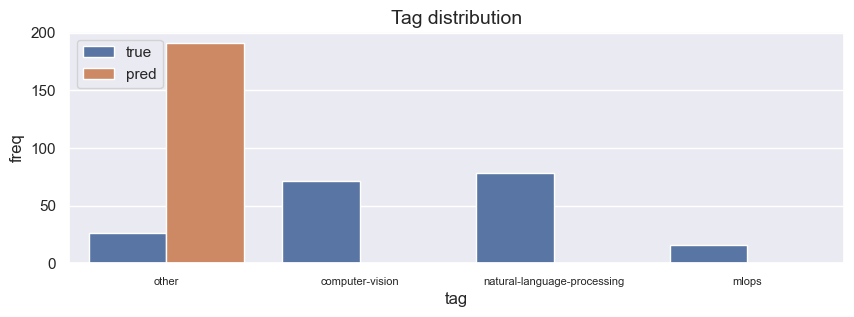

In [54]:
# Zero-shot with GPT 3.5
method = "zero_shot"
model = "gemini-2.5-flash-lite"
def clean_predictions(y_pred, tags, default="other"):
    for i, item in enumerate(y_pred):
        if item is None:  # Handle None predictions
            y_pred[i] = default
        elif item not in tags:  # hallucinations
            y_pred[i] = default
        elif item.startswith("'") and item.endswith("'"):  # GPT 4 likes to place quotes
            y_pred[i] = item[1:-1]
    return y_pred

y_pred[method][model], performance[method][model] = evaluate(
    test_df=test_df, model=model, system_content=system_content,
    assistant_content="", tags=tags)